#  판다스(Pandas)
- 분석·처리·정리하기 위해 가장 많이 쓰이는 오픈 소스 라이브러리
- 데이터를 빠르고 유연하게 처리할 수 있는 다양한 데이터 구조와 함수들을 제공
- 이름은 “Panel Data”에서 유래. 표 형태의 데이터(테이블)를 편리하게 다루도록 설계
- NumPy 기반으로 만들어져 있어 수치 계산, 통계 처리와 자연스럽게 통합

| 특징        | 설명                           |
| --------- | ---------------------------- |
| **언어**    | Python                       |
| **목적**    | 데이터 분석/정리/조작                 |
| **핵심 구조** | Series (1D), DataFrame (2D)  |
| **장점**    | 빠르고 유연한 데이터 처리, 다양한 파일 포맷 지원 |
| **응용 분야** | 데이터 사이언스, 머신러닝 전처리, 통계 분석 등  |


### Pandas로 할 수 있는 주요 작업
- 데이터 불러오기 / 저장  
CSV, Excel, JSON, SQL 테이블 등 다양한 포맷을 불러오고 저장  
- 데이터 정리(Cleaning)  
누락된 값 처리, 이상치 처리, 중복 제거, 문자열/날짜 형식 변환 등 다양한 정리 기능

- 데이터 탐색(Exploration)  
통계 요약(평균, 최대/최소), 상관관계 파악, 그룹화(GroupBy) 등의 분석이 가능  

- 데이터 조작(Manipulation)  
필터링, 정렬, 열/행 추가·제거, 데이터 병합/분할 등 다양한 조작이 가능  

- 시각화 연동  
Matplotlib, Seaborn 같은 시각화 라이브러리와도 잘 통합되어 데이터 시각화도 쉽게

# 1. Series - 1차원 배열 + 인덱스(label)
- 1차원 배열(사실상 dict)
- 인덱스가 붙은 리스트처럼 사용할 수 있습니다.  
예) 하나의 열(column)을 나타낼 때 유용  

Series  
 ├── Index  
 └── ndarray  <--- 여기에 값 저장


In [29]:
# %pip install --upgrade pip
# %pip install pandas
import pandas as pd

s = pd.Series([10, 20, 30, 40])  # 1차원 배열(레이블이 0부터 시작)
print(f"{s.values=}")
print(f"{s.index=}")
print(f"{s.dtype=}")
print(f"{s.shape=}")
print(f"{s.size=}")
print(s)

s.values=array([10, 20, 30, 40])
s.index=RangeIndex(start=0, stop=4, step=1)
s.dtype=dtype('int64')
s.shape=(4,)
s.size=4
0    10
1    20
2    30
3    40
dtype: int64


In [86]:
s = pd.Series([10, 20, 30], index=["a", "b", "c"]) # 레이블을 직접 지정가능
print(f"{s.values=}") # 넘파이 배열(ndarray)
print(f"{s.index=}")
print(f"{s.dtype=}")
print(f"{s.shape=}")
print(f"{s.size=}")
print(s)

s.values=array([10, 20, 30])
s.index=Index(['a', 'b', 'c'], dtype='str')
s.dtype=dtype('int64')
s.shape=(3,)
s.size=3
a    10
b    20
c    30
dtype: int64


### 슬라이싱

In [ ]:
s = pd.Series([10, 20, 30], index=["a", "b", "c"]) # 레이블을 직접 지정가능
print(f"{s.loc['a']=}")  # 레이블로 접근
print(f"{s.iloc[0]=}")   # 위치(index)로 접근


s.loc['a']=np.int64(10)
s.iloc[0]=np.int64(10)


In [ ]:
s = pd.Series([10, 20, 30], index=["a", "b", "c"]) # 레이블을 직접 지정가능
s.iloc[0:2]   # 위치 슬라이스.(끝 포함x)

a    10
b    20
dtype: int64

In [33]:
s = pd.Series([10, 20, 30], index=["a", "b", "c"]) # 레이블을 직접 지정가능
s.loc["a":"c"]  # 라벨 슬라이스 (끝 포함!)

a    10
b    20
c    30
dtype: int64

In [36]:
s = pd.Series([10, 20, 30, 40, 50])
s[s>20]  # boolean indexing

2    30
3    40
4    50
dtype: int64

In [55]:
data = {
    "서울": 100,
    "부산": 200,
    "대구": 150
}

s = pd.Series(data) # dict -> Series
s


서울    100
부산    200
대구    150
dtype: int64

## 1.2 연산

### 벡터 연산(numpy와 동일)

In [34]:
s = pd.Series([10, 20, 30], index=["a", "b", "c"]) # 레이블을 직접 지정가능

s + 10
s * 2
s > 15


a    False
b     True
c     True
dtype: bool

### 통계 함수
- s.count()
- s.mean()
- s.sum()
- s.min()
- s.max()
- s.std()
- s.describe()

In [53]:
s = pd.Series([1, 2, None, 4])
s.describe()

count    3.000000
mean     2.333333
std      1.527525
min      1.000000
25%      1.500000
50%      2.000000
75%      3.000000
max      4.000000
dtype: float64

### 형변환 - astype()

In [83]:
s = pd.Series([1, 2, 3, 4])
fs = s.astype(float)
fs

0    1.0
1    2.0
2    3.0
3    4.0
dtype: float64

### datetime으로 변환 - to_datetime()
- 문자열 → datetime 변환
- timestamp → datetime 변환
- 에러 안전 처리
- 타임존 처리
- 시간 기반 필터링 : df[df["date"] > "2026-02-01"]


In [114]:
import pandas as pd

dt = pd.to_datetime("2026-02-18")  # str -> pandas.Timestamp
# dt = pd.to_datetime("2026-02-18", format="%Y-%m-%d")  # 위와 동일

print(f"{dt.year=}")
print(f"{dt.month=}")
print(f"{dt.day=}")
print(f"{dt.weekday()=}") # 요일. 월요일은 0


dt.year=2026
dt.month=2
dt.day=18
dt.weekday()=2


### 람다식 변환 -  apply()

In [85]:
s = pd.Series([10, 20, 30, 40])  # 1차원 배열(레이블이 0부터 시작)
s2 = s.apply(lambda x : x * 10)
s2

0    100
1    200
2    300
3    400
dtype: int64

## 1.3 정렬 - 연산과정에서 자동 정렬되기도 함
- s.sort_values() : 값을 기준으로 정렬
- s.sort_index()  : 레이블을 기준으로 정렬

###  정렬이 안 되는 경우
- 서로 비교 불가능한 타입이 섞여 있을 때
- object 타입인데 내부 값이 비교 불가능

In [ ]:
s = pd.Series([1, 2, None, 4])
s.sort_values() # 값을 기준으로 정렬. 원본은 변경 없음
# s.sort_index(inplace=True) # 원본을 직접 변경

0    1.0
1    2.0
2    NaN
3    4.0
dtype: float64

In [ ]:
s = pd.Series([1, 2, None, 4])
# s.sort_index() # index를 기준으로 정렬(오름차순)
s.sort_index(ascending=False) # index를 기준으로 정렬(내림차순)

3    4.0
2    NaN
1    2.0
0    1.0
dtype: float64

In [81]:
s1 = pd.Series([1,2,3], index=["a","b","c"])
s2 = pd.Series([10,20,30], index=["b","c","d"])

s1 + s2  # 연산과정에서 자동 정렬. 자동 정렬로 맞춘후 연산

a     NaN
b    12.0
c    23.0
d     NaN
dtype: float64

### MultiIndex - index가 둘 이상인 경우

In [90]:
arrays = [
    ['A', 'A', 'B', 'B'],
    [2, 1, 2, 1]
]

index = pd.MultiIndex.from_arrays(arrays) # index가 2개

df = pd.DataFrame({'val': [10, 20, 30, 40]}, index=index)
print(f"{df.index=}")
df.sort_index() # multiIndex로 정렬

df.index=MultiIndex([('A', 2),
            ('A', 1),
            ('B', 2),
            ('B', 1)],
           )


val
A 1   20
  2   10
B 1   40
  2   30

In [75]:
arrays = [
    ['A', 'A', 'B', 'B'],
    [2, 1, 2, 1]
]

index = pd.MultiIndex.from_arrays(arrays) # index가 2개

df = pd.DataFrame({'val': [10, 20, 30, 40]}, index=index)
df.sort_index(level=1) # 특정 레벨만 정렬

,,val
A,1,20
B,1,40
A,2,10
B,2,30


In [76]:
arrays = [
    ['A', 'A', 'B', 'B'],
    [2, 1, 2, 1]
]

index = pd.MultiIndex.from_arrays(arrays) # index가 2개

df = pd.DataFrame({'val': [10, 20, 30, 40]}, index=index)
df.sort_index(level=[0,1], ascending=[True, False]) # 정렬 기준을 다르게


val
A 2   10
  1   20
B 2   30
  1   40

In [ ]:
arrays = [
    ['A', 'A', 'B', 'B'],
    [2, 1, 2, 1]
]

index = pd.MultiIndex.from_arrays(arrays) # index가 2개

df = pd.DataFrame({'val': [10, 20, 30, 40]}, index=index)
df.groupby(arrays[0]).sum().sort_index() # 첫번째 컬럼으로 groupby()후 sum()

,val
A,30
B,70


### kind (정렬 알고리즘)  - df.sort_index(kind='mergesort')
- 'quicksort' (기본)
- 'mergesort' (안정 정렬)
- 'heapsort'
- 'stable'

## 1.4  None의 처리

In [ ]:
s = pd.Series([1, 2, None, 4])
s.isna() # 각 요소가 None인지 확인. boolean타입의 Series반환

0    False
1    False
2     True
3    False
dtype: bool

In [50]:
s = pd.Series([1, 2, None, 4])
s.notna() # 각 요소가 None이 아닌지 확인. boolean타입의 Series반환

0     True
1     True
2    False
3     True
dtype: bool

In [51]:
s = pd.Series([1, 2, None, 4])
s.dropna() # None인 요소를 제거

0    1.0
1    2.0
3    4.0
dtype: float64

In [52]:
s = pd.Series([1, 2, None, 4])
s.fillna(0) # Npne을 0으로 치환


0    1.0
1    2.0
2    0.0
3    4.0
dtype: float64

# 2. Dataframe - 2차원 배열
- 행(row) + 열(column). 각 열은 하나의 Series(다른 타입 가능)
- 2차원 표(테이블) 형태의 데이터 구조
- 엑셀 시트나 SQL 테이블처럼 행(row)과 열(column)을 갖습니다.  
SQL + numpy + 엑셀의 장점 결합체

In [118]:
import pandas as pd

df = pd.DataFrame({
    "name": ["Alice", "Bob", "Charlie"],
    "age": [25, 30, 35],
    "score": [90, 85, 88]
})

df

,name,age,score
0,Alice,25,90
1,Bob,30,85
2,Charlie,35,88


## 2.1 DataFrame의 생성

### dict로 생성

In [119]:
pd.DataFrame({
    "A": [1,2,3],
    "B": [4,5,6]
})

,A,B
0,1,4
1,2,5
2,3,6


### list로 생성

In [120]:
pd.DataFrame(
    [[1,2], [3,4]],
    columns=["A","B"]
)

,A,B
0,1,2
1,3,4


### numpy 배열로 생성

In [121]:
import numpy as np

arr = np.array([[1,2], [3,4]])
pd.DataFrame(arr, columns=["A","B"])


,A,B
0,1,2
1,3,4


### CSV 파일 읽기

In [ ]:
%%writefile "file.csv"
df = pd.read_csv("file.csv")

Overwriting file.csv


## 2.2 DataFrame의 기본 속성

In [ ]:
df = pd.DataFrame({
    "name": ["Alice", "Bob", "Charlie"],
    "age": [25, 30, 35],
    "score": [90, 85, 88]
})

df.shape     # (행, 열)
df.columns   # 컬럼 목록
df.index     # 인덱스
df.dtypes    # 각 열의 타입
df.values    # numpy 배열
df.info()    # 전체 구조 출력
df.describe() # 통계 요약

<class 'pandas.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   name    3 non-null      str  
 1   age     3 non-null      int64
 2   score   3 non-null      int64
dtypes: int64(2), str(1)
memory usage: 204.0 bytes


,age,score
count,3.0,3.000000
mean,30.0,87.666667
std,5.0,2.516611
min,25.0,85.000000
25%,27.5,86.500000
50%,30.0,88.000000
75%,32.5,89.000000
max,35.0,90.000000


## 2.3 데이터 접근

In [132]:
df = pd.DataFrame({
    "name": ["Alice", "Bob", "Charlie"],
    "age": [25, 30, 35],
    "score": [90, 85, 88]
})
df["age"]       # Series 반환

0    25
1    30
2    35
Name: age, dtype: int64

In [134]:
df[["age"]]     # DataFrame 반환

,age
0,25
1,30
2,35


In [138]:
df[df["age"] > 28] # 조건 필터링

,name,age,score
1,Bob,30,85
2,Charlie,35,88


In [ ]:
df.iloc[0]  # 위치 기반 접근

name     Alice
age         25
score       90
Name: 0, dtype: object

In [136]:
df.loc[0] # 라벨 기반

name     Alice
age         25
score       90
Name: 0, dtype: object

In [156]:
df.at[0]

TypeError: DataFrame._get_value() missing 1 required positional argument: 'col'

## 2.4 컬럼 수정/추가/삭제
- df.assign()
- df.insert()
- df.drop()
- df.pop()
- df.rename()
- df.set_index()
- df.reset_index()

In [163]:
df.assign(new_col=df["age"]*2) # 새로운 컬럼 추가

,name,age,score,grade,new_col
0,Alice,28,90,A,56
1,Bob,33,85,B,66
2,Charlie,38,88,B,76


In [173]:
df.rename(0)

TypeError: Index(...) must be called with a collection of some kind, 0 was passed

In [168]:
df.drop(0) # 첫 번째 행 삭제

,name,age,score,grade
1,Bob,34,85,B
2,Charlie,39,88,B


In [169]:
df["grade"] = ["A", "B", "B"] # 컬럼 "grade" 추가
df["age"] = df["age"] + 1     # 컬럼에 저장된 값 변경
df

,name,age,score,grade
0,Alice,30,90,A
1,Bob,35,85,B
2,Charlie,40,88,B


In [170]:
df.drop("score", axis=1) # 컬럼 삭제

,name,age,grade
0,Alice,30,A
1,Bob,35,B
2,Charlie,40,B


## 2.5 DataFrame의 메서드

### 데이터 확인/탐색 메서드
- 데이터 구조 파악
- 결측치 확인
- 통계 요약

In [154]:
df.head(2) # 처음 2줄만. head()는 처음 5줄
df.tail(2) # 마지막 2줄만

df.sample()
df.info()
df.describe()
df.value_counts()
df.nunique()
df.isna()
df.notna()

<class 'pandas.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   name    3 non-null      str  
 1   age     3 non-null      int64
 2   score   3 non-null      int64
 3   grade   3 non-null      str  
dtypes: int64(2), str(2)
memory usage: 228.0 bytes


,name,age,score,grade
0,True,True,True,True
1,True,True,True,True
2,True,True,True,True


### 인덱싱/선택 관련
- at : 단일 값 빠른 접근
- filter() : 조건으로 거르기
- query() : SQL스타일 조건

In [186]:
df.at[2, "age"]  # 읽기(레이블 기반) row=2, col="age"
df.at[2, "age"] = 100 # 쓰기
df.iat[2, 1]     # 읽기(위치기반). 위와 동일

np.int64(100)

In [177]:
df.query("age > 30")

,name,age,score,grade
1,Bob,35,85,B
2,Charlie,40,88,B


In [ ]:

df = pd.DataFrame({
    "name": ["A", "B", "C"],
    "age": [10, 20, 30],
    "score": [90, 80, 70]
})

df.filter(items=["name", "score"])
# df.filter(like="sc")  # 문자열에 "sc"포함
# df.filter(regex="^s") # 정규식 사용가능

,name,score
0,A,90
1,B,80
2,C,70


### 정렬 / 순서 변경
- df.sort_values()
- df.sort_index()
- df.reindex() : 행, 컬럼 순서 변경
- df.reindex_like()

In [192]:

df = pd.DataFrame({
    "name": ["A", "B", "C"],
    "age": [10, 20, 30],
    "score": [90, 80, 70]
})

df.sort_values("age", ascending=False)

,name,age,score
2,C,30,70
1,B,20,80
0,A,10,90


In [195]:
df = pd.DataFrame({'A': [1,2,3], 'B': [4,5,6]})
df2 = df.reindex([2,0,1]) # 0,1,2 -> 2,0,1  인덱스의 순서를 변경
df2

,A,B
2,3,6
0,1,4
1,2,5


### 집계 / 통계
- df.sum()
- df.mean()
- df.min()
- df.max()
- df.count()
- df.std()
- df.var()
- df.median()
- df.corr()
- df.cov()

### groupby 관련
- df.groupby()
- df.agg()
- df.aggregate()
- df.transform()
- df.apply()
- df.filter()


In [203]:
df = pd.DataFrame({
    'city': ['A','A','B','B','C'],
    'value': [10, 20, 30, 40, 50]
})

df.groupby('city')['value'].sum()
# df.groupby('city')['value'].agg('sum') # 위와 동일
# df2.groupby(['city','type'])['value'].sum() # multi-grouping

city
A    30
B    70
C    50
Name: value, dtype: int64

In [201]:
df.groupby('city')['value'].agg(['sum','mean','count'])

,sum,mean,count
city,,,
A,30,15.0,2
B,70,35.0,2
C,50,50.0,1


In [211]:
df = pd.DataFrame({
    'city': ['A','A','B','B','C'],
    'value': [10, 20, 30, 40, 50],
    'price': [100, 200, 150, 250, 300]
})

df.groupby('city').agg({
    'value': 'sum',
    'price': 'mean'
})

,value,price
city,,
A,30,150.0
B,70,200.0
C,50,300.0


### 병합 / 결합
- df.merge()   : 컬럼기준 병합. SQL의 join
- df.join() : 인덱스 기준 
- pd.concat() 
- df.update() : 기존 df값만 수정
- df.combine_first()

| how   | 의미     | SQL과 동일    |
| ----- | ------ | ---------- |
| inner | 교집합    | INNER JOIN |
| left  | 왼쪽 기준  | LEFT JOIN  |
| right | 오른쪽 기준 | RIGHT JOIN |
| outer | 합집합    | FULL OUTER |


In [214]:
df = pd.DataFrame({
    'city': ['A','A','B','B','C'],
    'value': [10, 20, 30, 40, 50],
})

df2 = pd.DataFrame({
    'city': ['A','A','B','B','C'],
    'price': [100, 200, 150, 250, 300]
})

pd.merge(df, df2, on='city', how='inner')
# pd.merge(df, df2, left_on='city', right_on='city_id') # 컬럼명이 다를 때


,city,value,price
0,A,10,100
1,A,10,200
2,A,20,100
3,A,20,200
4,B,30,150
5,B,30,250
6,B,40,150
7,B,40,250
8,C,50,300


In [221]:
df = pd.DataFrame({
    'value': [10, 20, 30, 40, 50],
})

df2 = pd.DataFrame({
    'price': [100, 200, 150, 250, 300]
})

df.join(df2) # 인덱스 기반 병합

,value,price
0,10,100
1,20,200
2,30,150
3,40,250
4,50,300


In [231]:
df = pd.DataFrame({
    'value': [10, 20, 30, 40, 50],
})

df2 = pd.DataFrame({
    'price': [100, 200, 150, 250, 300]
})

pd.concat([df, df2]) # 단순히 두개를 붙이기(위, 아래)
# pd.concat([df, df2], axis=0) # 위와 동일

,value,price
0,10.0,NaN
1,20.0,NaN
2,30.0,NaN
3,40.0,NaN
4,50.0,NaN
0,NaN,100.0
1,NaN,200.0
2,NaN,150.0
3,NaN,250.0
4,NaN,300.0


In [227]:
df = pd.DataFrame({
    'value': [10, 20, 30, 40, 50],
})

df2 = pd.DataFrame({
    'price': [100, 200, 150, 250, 300]
})

pd.concat([df, df2], axis=1) # 단순히 두개를 붙이기(좌우)

,value,price
0,10,100
1,20,200
2,30,150
3,40,250
4,50,300


In [246]:
df = pd.DataFrame({
    'price': [999, 888]
})

df2 = pd.DataFrame({
    'price': [100, 200, 150, 250, 300]
})

df.update(df2) # 겹치는 부분만 변경. [999,888] -> [100,200]
df

,price
0,100
1,200


### 결측치 처리
- df.fillna()
- df.dropna()
- df.interpolate()

### 데이터 변형
- df.pivot()
- df.pivot_table()
- df.melt()
- df.stack()
- df.unstack()
- df.explode()

### 문자열 처리 (Series 중심)
- df["col"].str.lower()
- df["col"].str.contains()

### 날짜 처리
- df["date"].dt.year
- df["date"].dt.month

### 타입 변환
- df.astype()
- df.convert_dtypes()
- df.infer_objects()

### 고급 연산
- df.apply()
- df.applymap()
- df.pipe() : 체이닝(메서드 연결)에 사용
- df.eval() : 문자열 수식 실행

### 메서드 체이닝

In [175]:
(
    df
    .query("age > 30")
    .assign(double=lambda x: x.age*2)
    .sort_values("double")
)


,name,age,score,grade,double
1,Bob,35,85,B,70
2,Charlie,40,88,B,80


# 3. Pandas의 시각화

- Pandas 시각화는 “데이터 확인용 초고속 도구
- DataFrame.plot() = 내부적으로 Matplotlib을 감싼 wrapper  
DataFrame.plot()  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;    ↓  
PlotAccessor  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;    ↓  
matplotlib.axes.Axes  

### Pandas 시각화의 한계
- 빠른 EDA에는 최고
- 정교한 커스터마이징은 불편
- 복잡한 레이아웃 힘듦 -> 보고서용에는 Seaborn, Plotly

### Seaborn이 더 좋은 이유
- 통계기반 시각화
- 기본 디자인이 훨씬 예쁨
- 범주형 데이터 강함

Note: you may need to restart the kernel to use updated packages.


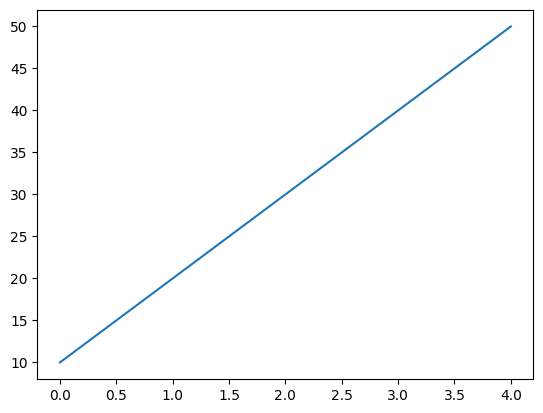

In [269]:
%pip install matplotlib
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame({
    'city': ['A','A','B','B','C'],
    'value': [10, 20, 30, 40, 50],
})

plt.figure()
plt.plot(df['value'])
plt.show()

Note: you may need to restart the kernel to use updated packages.


<Axes: xlabel='city', ylabel='value'>

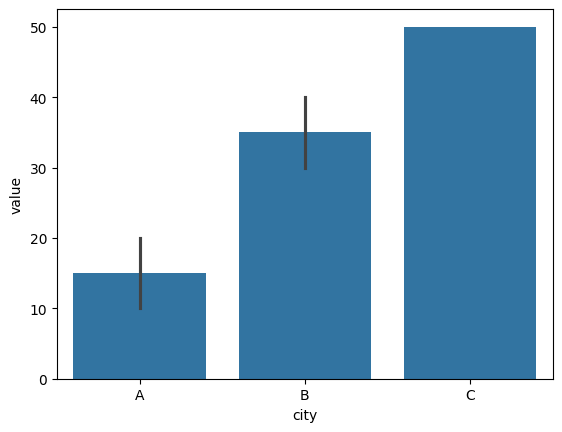

In [2]:
%pip install seaborn
import pandas as pd
import seaborn as sns

df = pd.DataFrame({
    'city': ['A','A','B','B','C'],
    'value': [10, 20, 30, 40, 50],
})

sns.barplot(data=df, x="city", y="value")

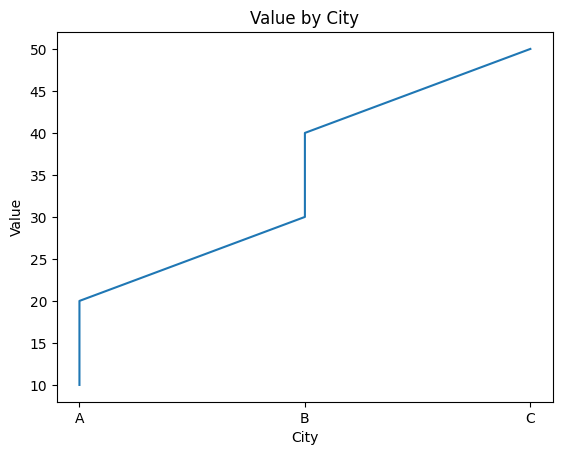

In [271]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(df['city'], df['value'])
plt.xlabel('City')
plt.ylabel('Value')
plt.title('Value by City')
plt.show()


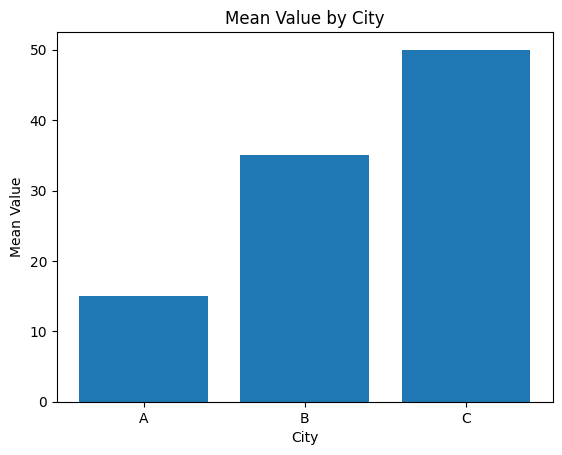

In [272]:
grouped = df.groupby('city')['value'].mean()

plt.figure()
plt.bar(grouped.index, grouped.values)
plt.xlabel('City')
plt.ylabel('Mean Value')
plt.title('Mean Value by City')
plt.show()


<Axes: >

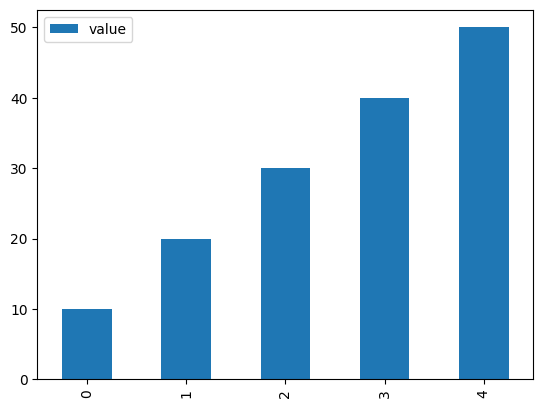

In [276]:
grouped = df.groupby('city')['value'].mean()

df.plot(kind="bar")

<Axes: xlabel='city'>

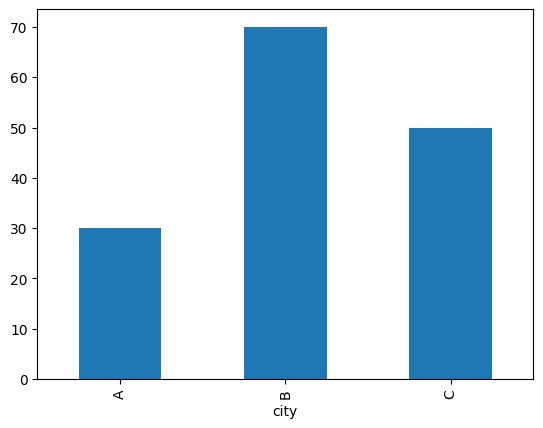

In [279]:
df.groupby("city")["value"].sum().plot(kind="bar")

<Axes: title={'center': 'Sales Trend'}>

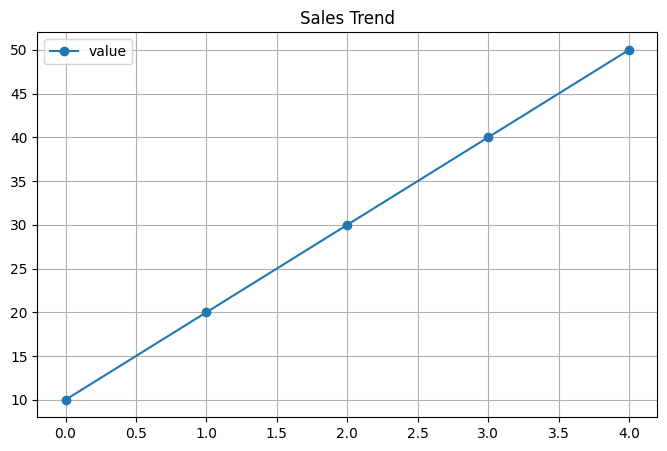

In [281]:
df.plot(
    kind="line",
    figsize=(8,5),
    title="Sales Trend",
    grid=True,
    marker="o"
)


<Axes: >

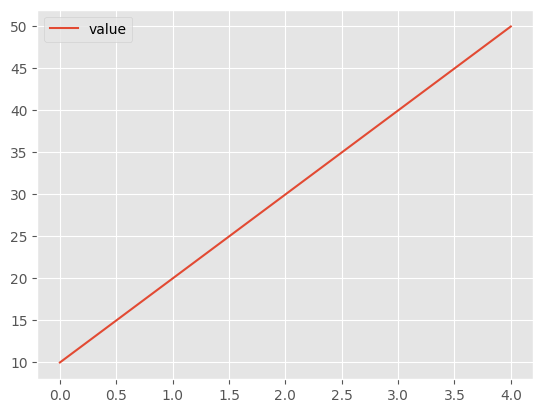

In [3]:
import matplotlib.pyplot as plt
plt.style.use("ggplot")
df.plot()

<Axes: >

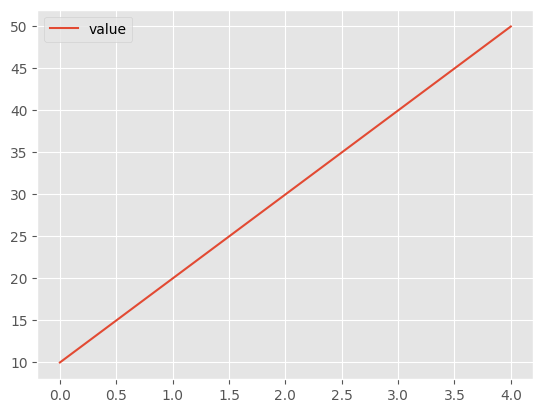

In [11]:
df[["city", "value"]].plot() # 특정 컬럼만 선택